# Figure 5i-k - Prediction of neural activity from facial features

This notebook contains the code to reproduce Fig 5i-k. To run this code, you need the following Anipose projects:
- `20240823_ephys-all_rig1_score_0_75_frozen`
- `202505-ephys-record`

as well as corresponding electrophysiology data for each recording in the Anipose project.

In [ ]:
%load_ext autoreload
%autoreload 2

# Update path as if notebook was run from top-level repo directory
import os
import sys

pwd = %pwd
if pwd.endswith('notebooks'):
    sys.path.insert(0, os.path.abspath('..'))
    new_pwd = os.path.abspath(f"{pwd}/..")
    %cd {new_pwd}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Define the mapping from recording to craniotomy and spike QC.

In [ ]:
CRANIOTOMY_MAP = {
    "R20": "right",
    "R22": "left",
    "R28": "right",
    "B1": {
        "20250513": "right",
        "20250514": "right",
        "20250515": "right",
        "20250516": "right",
        "20250518": "right",
        "20250519": "right",
        "20250520": "left",
        "20250521": "left",
        "20250522": "left",
        "20250523": "left",
    }
}

BAD_UNITS = {
    ("20250514", "000"): [
        "cluster36",
        "cluster48",
        "cluster3",
    ],
    ("20250514", "001"): [
        "cluster72"
    ],
    ("20250515", "000"): [
        "cluster78",
        "cluster79",
        "cluster59"
    ],
    ("20250515", "002"): [
        "cluster5"
    ],
    ("20250515", "004"): [
        "cluster67",
        "cluster68",
    ],
    ("20250516", "000"): [
        "cluster6",
        "cluster9",
        "cluster19",
        "cluster60"
    ],
    ("20250516", "002"): [
        "cluster15",
        "cluster39",
        "cluster51"
    ],
    ("20250520", "000"): [
        "cluster1",
        "cluster34",
        "cluster75",
        "cluster78"
    ],
    ("20250520", "002"): [
        "cluster2",
        "cluster26",
        "cluster38"
    ],
    ("20250521", "000"): [
        "cluster45"
    ],
    ("20250521", "003"): [
        "cluster8",
    ],
    ("20250521", "006"): [
        "cluster12",
        "cluster22",
        "cluster70"
    ],
    ("20250522", "000"): [
        "cluster7",
        "cluster12",
        "cluster21",
        "cluster32",
        "cluster2",
        "cluster6",
        "cluster26"
    ]
}

MERGE_UNITS = {
    ("20250514", "001"): [
        "cluster38",
        "cluster39",
    ],
    ("20250515", "000"): [
        "cluster33",
        "cluster72",
        "cluster73",
    ],
    ("20250518", "000"): [
        "cluster51",
        "cluster55",
        "cluster56",
    ],
    ("20250518", "002"): [
        "cluster0",
        "cluster30",
    ],
    ("20250521", "003"): [
        "cluster40",
        "cluster84",
        "cluster135"
    ]
}

In [ ]:
# set to None for CPU, or set to GPU ID
GPU = 1

os.environ["CUDA_VISIBLE_DEVICES"] = "" if GPU is None else str(GPU)
import jax

jax.devices()

[cuda(id=0)]

In [ ]:
import itertools
import shutil
import jax.numpy as jnp
import lineax as lx
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import nemos as nmo
from math import ceil
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
from pqdm.processes import pqdm
from glob import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from scipy.ndimage import median_filter
from functools import partial
from typing import Optional

from fepipeline.features.landmarks import read_3d_data
from fepipeline.anatomy import compute_measurements_df

from labutils.plotting import (sns_setup,
                               landmark_cmap,
                               measurements_cmap,
                               save_figure)
from labutils.utils import maybe, flat_list

def moving_average(timeseries, window_size = 5, axis = 0):
    if timeseries.ndim == 1:
        return np.convolve(timeseries, np.ones(window_size) / window_size, mode='valid')
    else:
        return np.apply_along_axis(
            lambda x: np.convolve(x, np.ones(window_size) / window_size, mode='valid'),
            axis=axis, arr=timeseries
        )

sns_setup(palette="colorblind", font="sans-serif")
OUTPUT_DIR = Path("./figures/ephys-prediction")
os.makedirs(OUTPUT_DIR, exist_ok=True)

_, LANDMARK_CMAP = landmark_cmap()
_, MEASUREMENT_CMAP = measurements_cmap()

BBOX_MAP = defaultdict(lambda: {
    "BC": (430, 440, 10, 20),
    "TC": (390, 400, 110, 120),
    "L": (165, 175, 90, 100),
    "R": (480, 490, 80, 90),
    "TL": (245, 255, 90, 100)
})

CACHE = "measurements-data-cache"
MODEL_CACHE = Path(CACHE) / "ephys-models"

CONTROL_CMAP = sns.color_palette([sns.color_palette("colorblind")[2],
                                  sns.color_palette("colorblind")[-3],
                                  sns.color_palette("colorblind")[3]])

ANIPOSE_PATHS = {"premotor": "anipose-projects/20240823_ephys-all_rig1_score_0_75_frozen",
                 "motor": "anipose-projects/202505-ephys-record"}
COORDINATE_PATHS = {}
key_cols = ("date", "mouse", "run", "recording_site")
for location, p in sorted((location, p)
                          for location, path in ANIPOSE_PATHS.items()
                          for p in Path(path).glob('*/pose-3d/*.csv')):
    date, mouse, *_, run, _ = p.name.split("_")
    if mouse == "M22":
        mouse = "R22"
    elif mouse == "M28":
        mouse = "R28"
    if not (date.startswith("2024") or date.startswith("2025052")):
        continue
    if date == "20250520" or date == "20250522":
        continue
    # if date.startswith("2024") and date != "20240918":
    #     continue
    if date == "20250521" and run == "002":
        continue
    COORDINATE_PATHS[(date, mouse, run, location)] = p
data_keys = list(COORDINATE_PATHS.keys())
data_keys

[('20250521', 'B1', '000', 'motor'),
 ('20250521', 'B1', '003', 'motor'),
 ('20250521', 'B1', '006', 'motor'),
 ('20250523', 'B1', '000', 'motor'),
 ('20240819', 'R20', '000', 'premotor'),
 ('20240820', 'R20', '001', 'premotor'),
 ('20240823', 'R22', '003', 'premotor'),
 ('20240918', 'R28', '000', 'premotor'),
 ('20240919', 'R28', '000', 'premotor')]

In [ ]:
# set to None for CPU, or set to GPU ID
GPU = 1

os.environ["CUDA_VISIBLE_DEVICES"] = "" if GPU is None else str(GPU)
import jax

jax.devices()

[cuda(id=0)]

In [ ]:
import itertools
import shutil
import jax.numpy as jnp
import lineax as lx
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import nemos as nmo
from math import ceil
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
from pqdm.processes import pqdm
from glob import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from scipy.ndimage import median_filter
from functools import partial
from typing import Optional

from fepipeline.features.landmarks import read_3d_data
from fepipeline.anatomy import compute_measurements_df

from labutils.plotting import (sns_setup,
                               landmark_cmap,
                               measurements_cmap,
                               save_figure)
from labutils.utils import maybe, flat_list

def moving_average(timeseries, window_size = 5, axis = 0):
    if timeseries.ndim == 1:
        return np.convolve(timeseries, np.ones(window_size) / window_size, mode='valid')
    else:
        return np.apply_along_axis(
            lambda x: np.convolve(x, np.ones(window_size) / window_size, mode='valid'),
            axis=axis, arr=timeseries
        )

sns_setup(palette="colorblind", font="sans-serif")
OUTPUT_DIR = Path("./figures/ephys-prediction")
os.makedirs(OUTPUT_DIR, exist_ok=True)

_, LANDMARK_CMAP = landmark_cmap()
_, MEASUREMENT_CMAP = measurements_cmap()

BBOX_MAP = defaultdict(lambda: {
    "BC": (430, 440, 10, 20),
    "TC": (390, 400, 110, 120),
    "L": (165, 175, 90, 100),
    "R": (480, 490, 80, 90),
    "TL": (245, 255, 90, 100)
})

CACHE = "measurements-data-cache"
MODEL_CACHE = Path(CACHE) / "ephys-models"

CONTROL_CMAP = sns.color_palette([sns.color_palette("colorblind")[2],
                                  sns.color_palette("colorblind")[-3],
                                  sns.color_palette("colorblind")[3]])

ANIPOSE_PATHS = {"premotor": "anipose-projects/20240823_ephys-all_rig1_score_0_75_frozen",
                 "motor": "anipose-projects/202505-ephys-record"}
COORDINATE_PATHS = {}
key_cols = ("date", "mouse", "run", "recording_site")
for location, p in sorted((location, p)
                          for location, path in ANIPOSE_PATHS.items()
                          for p in Path(path).glob('*/pose-3d/*.csv')):
    date, mouse, *_, run, _ = p.name.split("_")
    if mouse == "M22":
        mouse = "R22"
    elif mouse == "M28":
        mouse = "R28"
    if not (date.startswith("2024") or date.startswith("2025052")):
        continue
    if date == "20250520" or date == "20250522":
        continue
    # if date.startswith("2024") and date != "20240918":
    #     continue
    if date == "20250521" and run == "002":
        continue
    COORDINATE_PATHS[(date, mouse, run, location)] = p
data_keys = list(COORDINATE_PATHS.keys())
data_keys

[('20250521', 'B1', '000', 'motor'),
 ('20250521', 'B1', '003', 'motor'),
 ('20250521', 'B1', '006', 'motor'),
 ('20250523', 'B1', '000', 'motor'),
 ('20240819', 'R20', '000', 'premotor'),
 ('20240820', 'R20', '001', 'premotor'),
 ('20240823', 'R22', '003', 'premotor'),
 ('20240918', 'R28', '000', 'premotor'),
 ('20240919', 'R28', '000', 'premotor')]

# Load datasets

Load 3D behavioral traces.

In [ ]:
coord_data = {k: read_3d_data(v.parent.parent.as_posix(),
                              extra_cols=["ncams", "score"])
              for k, v in COORDINATE_PATHS.items()}

meas_df = compute_measurements_df({k: v[0] for k, v in coord_data.items()},
                                  key_columns=key_cols)
meas_df.head()

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,measurement_value,std,count,timeseries
0,20250521,B1,000,motor,eye,eye-height-left,mm,distance,1.968570,0.159357,120907,"[2.036134521287978, 2.0388281479945434, 2.0355..."
36,20250521,B1,006,motor,eye,eye-width-left,mm,distance,3.069441,0.177660,125261,"[3.1547604712298507, 3.147079733471757, 3.1436..."
37,20250521,B1,006,motor,eye,eye-width-right,mm,distance,3.074247,0.226099,125261,"[2.9329319407991146, 2.9342495170358758, 2.930..."
38,20250521,B1,006,motor,eye,eye-area-left,mm^2,area,3.094687,0.770036,125261,"[3.3846771350494906, 3.392277031076371, 3.3872..."
39,20250521,B1,006,motor,eye,eye-area-right,mm^2,area,3.268715,0.767332,125261,"[2.3632580623112784, 2.3588261176157324, 2.363..."


In [ ]:
# add craniotomy side to measurement df
meas_df["craniotomy"] = meas_df[["date", "mouse"]].apply(
    lambda row: CRANIOTOMY_MAP[row["mouse"]]
                if isinstance(CRANIOTOMY_MAP[row["mouse"]], str)
                else CRANIOTOMY_MAP[row["mouse"]][row["date"]],
    axis=1
)
# add sample rate, etc.
meas_df["sample_rate"] = 100.0
meas_df["lag_time"] = 0.0
# add start and end times
meas_df["start_time"] = 0.0
meas_df["end_time"] = meas_df["start_time"] + (meas_df["count"] / meas_df["sample_rate"])
# drop measurement value, std, and count columns
meas_df = meas_df.drop(columns=["measurement_value", "std", "count"])
meas_df.head()

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,craniotomy,sample_rate,lag_time,start_time,end_time
0,20250521,B1,000,motor,eye,eye-height-left,mm,distance,"[2.036134521287978, 2.0388281479945434, 2.0355...",left,100.0,0.0,0.0,1209.07
36,20250521,B1,006,motor,eye,eye-width-left,mm,distance,"[3.1547604712298507, 3.147079733471757, 3.1436...",left,100.0,0.0,0.0,1252.61
37,20250521,B1,006,motor,eye,eye-width-right,mm,distance,"[2.9329319407991146, 2.9342495170358758, 2.930...",left,100.0,0.0,0.0,1252.61
38,20250521,B1,006,motor,eye,eye-area-left,mm^2,area,"[3.3846771350494906, 3.392277031076371, 3.3872...",left,100.0,0.0,0.0,1252.61
39,20250521,B1,006,motor,eye,eye-area-right,mm^2,area,"[2.3632580623112784, 2.3588261176157324, 2.363...",left,100.0,0.0,0.0,1252.61


Load ephys recording data (already sorted and good cluster spike times extracted).

In [ ]:
def build_ephys_df_xdat(data_keys, craniotomy):
    df = []
    for date, mouse, run, site in tqdm(data_keys, desc="reading ephys"):
        # read alignment file
        xdat_source = glob(f"ephys-data/{date}*_rig1/{mouse}_{int(run)}_*.xdat.json")
        if len(xdat_source) == 1:
            xdat_source = Path(xdat_source[0])
            # we assume the lag_time and sample_rate are exact for spike-times_good
            lag_time = 0
            sample_rate = 30000
            # align_source = Path(str(xdat_source).replace("xdat", "align"))
            # if align_source.exists():
            #     with open(align_source) as f:
            #         alignment = json.load(f)
            #         # lag_time = alignment["lag_time"]
            #         lag_time = 0 # "good" cluster times are already aligned
            #         sample_rate = alignment["sample_rate"]
            # else:
            #     lag_time = 0
            #     sample_rate = 30000
            #     print("WARNING: no alignment file found for", date, mouse, run)
            craniotomy_side = craniotomy[mouse]
            if not isinstance(craniotomy_side, str):
                craniotomy_side = craniotomy_side[date]
            # read cluster spike times
            if site == "premotor":
                cluster_sources = glob(str(xdat_source.parent / "spike-time_good/cluster*.npy"))
            elif site == "motor":
                cluster_sources = glob(str(xdat_source.parent /
                                           f"{mouse}_{date}_{int(run)}" /
                                           "spike-time_good/cluster*.npy"))
            else:
                print("WARNING: unknown recording site", site, "for", date, mouse, run)
                continue
            for cluster_source in cluster_sources:
                cluster = str(Path(cluster_source).name.removesuffix(".npy")).replace("_", "")
                # use np.unique to remove double counted spikes
                # this is a phy bug
                spikes = np.unique(np.load(cluster_source))
                df.append({
                    "date": date,
                    "mouse": mouse,
                    "run": run,
                    "recording_site": site,
                    "measurement_group": "ephys",
                    "measurement_name": cluster,
                    "measurement_units": "sec",
                    "measurement_type": "spike_times",
                    "timeseries": spikes[:, 0] if spikes.ndim > 1 else spikes,
                    "craniotomy": craniotomy_side,
                    "sample_rate": sample_rate,
                    "lag_time": lag_time
                })
        else:
            print("WARNING: no xdat file found for", date, mouse, run)
            continue

    df = pd.DataFrame(df)

    return df

ephys_df = build_ephys_df_xdat(data_keys, CRANIOTOMY_MAP)
ephys_df

reading ephys:   0%|          | 0/9 [00:00<?, ?it/s]

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,craniotomy,sample_rate,lag_time
0,20250521,B1,000,motor,ephys,cluster39,sec,spike_times,"[43.11569990469078, 79.9472252123532, 79.95145...",left,30000,0
1,20250521,B1,000,motor,ephys,cluster29,sec,spike_times,"[0.24168034203562894, 0.5174451358408979, 0.54...",left,30000,0
2,20250521,B1,000,motor,ephys,cluster54,sec,spike_times,"[0.607746872182925, 0.6274182050904584, 0.6438...",left,30000,0
3,20250521,B1,000,motor,ephys,cluster45,sec,spike_times,"[8.841980432243766, 23.735775659772393, 23.875...",left,30000,0
4,20250521,B1,003,motor,ephys,cluster84,sec,spike_times,"[1.5978602350231914, 2.551028418861608, 4.8040...",left,30000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
78,20240919,R28,000,premotor,ephys,cluster24,sec,spike_times,"[9.909883626247833, 17.110566029514956, 17.177...",right,30000,0
79,20240919,R28,000,premotor,ephys,cluster41,sec,spike_times,"[9.107574653420619, 9.12637954728995, 9.149164...",right,30000,0
80,20240919,R28,000,premotor,ephys,cluster2,sec,spike_times,"[0.13047650865577645, 0.13929855763151283, 0.1...",right,30000,0
81,20240919,R28,000,premotor,ephys,cluster25,sec,spike_times,"[0.3673120414968801, 0.38896917676438336, 0.45...",right,30000,0


Drop clusters that are `BAD_UNITS`.

In [ ]:
rows_to_drop = []
for date, _, run, _ in data_keys:
    if (date, run) in BAD_UNITS:
        bad_clusters = BAD_UNITS[(date, run)]
        # Find indices of rows that match current date, run, and bad clusters
        mask = (
            (ephys_df["date"] == date) & 
            (ephys_df["run"] == run) & 
            (ephys_df["measurement_name"].isin(bad_clusters))
        )
        rows_to_drop.extend(ephys_df[mask].index.tolist())

# Drop all identified bad units
ephys_df = ephys_df.drop(index=rows_to_drop)
ephys_df

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,craniotomy,sample_rate,lag_time
0,20250521,B1,000,motor,ephys,cluster39,sec,spike_times,"[43.11569990469078, 79.9472252123532, 79.95145...",left,30000,0
1,20250521,B1,000,motor,ephys,cluster29,sec,spike_times,"[0.24168034203562894, 0.5174451358408979, 0.54...",left,30000,0
2,20250521,B1,000,motor,ephys,cluster54,sec,spike_times,"[0.607746872182925, 0.6274182050904584, 0.6438...",left,30000,0
4,20250521,B1,003,motor,ephys,cluster84,sec,spike_times,"[1.5978602350231914, 2.551028418861608, 4.8040...",left,30000,0
5,20250521,B1,003,motor,ephys,cluster135,sec,spike_times,"[0.44944518292356833, 9.856043875906167, 10.63...",left,30000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
78,20240919,R28,000,premotor,ephys,cluster24,sec,spike_times,"[9.909883626247833, 17.110566029514956, 17.177...",right,30000,0
79,20240919,R28,000,premotor,ephys,cluster41,sec,spike_times,"[9.107574653420619, 9.12637954728995, 9.149164...",right,30000,0
80,20240919,R28,000,premotor,ephys,cluster2,sec,spike_times,"[0.13047650865577645, 0.13929855763151283, 0.1...",right,30000,0
81,20240919,R28,000,premotor,ephys,cluster25,sec,spike_times,"[0.3673120414968801, 0.38896917676438336, 0.45...",right,30000,0


Merge units that are the same.

In [ ]:
# Create a dataframe to store the merged rows
merged_rows = []
# Keep track of indices to drop
rows_to_drop = []
# Loop through each entry in MERGE_UNITS
for (date, run), clusters in MERGE_UNITS.items():
    # Find all rows that match this date, run, and any of the clusters
    mask = (
        (ephys_df["date"] == date) & 
        (ephys_df["run"] == run) & 
        (ephys_df["measurement_name"].isin(clusters))
    )
    matching_rows = ephys_df[mask]
    if not matching_rows.empty:
        # Get the first row to use as a template for metadata
        template_row = matching_rows.iloc[0].copy()
        # Create a new measurement name by joining the cluster names
        new_measurement_name = "cluster" + "_".join(
            [s.replace("cluster", "") for s in clusters]
        )
        # Create a union of all timeseries data
        all_spikes = []
        for _, row in matching_rows.iterrows():
            all_spikes.extend(row["timeseries"])
        # Sort the combined spike times and remove duplicates
        merged_timeseries = np.sort(np.unique(all_spikes))
        # Update the template row with the new information
        template_row["measurement_name"] = new_measurement_name
        template_row["timeseries"] = merged_timeseries
        # Add to our list of merged rows
        merged_rows.append(template_row)
        # Record the indices to drop
        rows_to_drop.extend(matching_rows.index.tolist())
# Drop the original rows that were merged
ephys_df = ephys_df.drop(index=rows_to_drop)
# Append the merged rows to ephys_df
if merged_rows:
    ephys_df = pd.concat([ephys_df, pd.DataFrame(merged_rows)], ignore_index=True)
ephys_df

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,craniotomy,sample_rate,lag_time
0,20250521,B1,000,motor,ephys,cluster39,sec,spike_times,"[43.11569990469078, 79.9472252123532, 79.95145...",left,30000,0
1,20250521,B1,000,motor,ephys,cluster29,sec,spike_times,"[0.24168034203562894, 0.5174451358408979, 0.54...",left,30000,0
2,20250521,B1,000,motor,ephys,cluster54,sec,spike_times,"[0.607746872182925, 0.6274182050904584, 0.6438...",left,30000,0
3,20250521,B1,003,motor,ephys,cluster113,sec,spike_times,"[2.192055102428416, 3.3732886700591584, 4.9289...",left,30000,0
4,20250521,B1,003,motor,ephys,cluster20,sec,spike_times,"[0.48346194040105767, 3.0003025797531455, 3.04...",left,30000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
72,20240919,R28,000,premotor,ephys,cluster41,sec,spike_times,"[9.107574653420619, 9.12637954728995, 9.149164...",right,30000,0
73,20240919,R28,000,premotor,ephys,cluster2,sec,spike_times,"[0.13047650865577645, 0.13929855763151283, 0.1...",right,30000,0
74,20240919,R28,000,premotor,ephys,cluster25,sec,spike_times,"[0.3673120414968801, 0.38896917676438336, 0.45...",right,30000,0
75,20240919,R28,000,premotor,ephys,cluster38,sec,spike_times,"[0.19206502349766547, 0.2469540876136193, 0.27...",right,30000,0


Remove double counted spikes and add start/end times.

In [ ]:
ephys_df["timeseries"] = ephys_df["timeseries"].apply(
    lambda x: np.sort(np.unique(x))
)
ephys_df["start_time"] = ephys_df.apply(
    lambda row: meas_df[
        (meas_df["date"] == row["date"]) &
        (meas_df["mouse"] == row["mouse"]) &
        (meas_df["run"] == row["run"])
    ]["start_time"].values[0],
    axis=1
)
ephys_df["end_time"] = ephys_df.apply(
    lambda row: max(row["timeseries"].max(), meas_df[
        (meas_df["date"] == row["date"]) &
        (meas_df["mouse"] == row["mouse"]) &
        (meas_df["run"] == row["run"])
    ]["end_time"].values[0]),
    axis=1
)
ephys_df

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,craniotomy,sample_rate,lag_time,start_time,end_time
0,20250521,B1,000,motor,ephys,cluster39,sec,spike_times,"[43.11569990469078, 79.9472252123532, 79.95145...",left,30000,0,0.0,1209.070000
1,20250521,B1,000,motor,ephys,cluster29,sec,spike_times,"[0.24168034203562894, 0.5174451358408979, 0.54...",left,30000,0,0.0,1209.070000
2,20250521,B1,000,motor,ephys,cluster54,sec,spike_times,"[0.607746872182925, 0.6274182050904584, 0.6438...",left,30000,0,0.0,1209.639588
3,20250521,B1,003,motor,ephys,cluster113,sec,spike_times,"[2.192055102428416, 3.3732886700591584, 4.9289...",left,30000,0,0.0,1228.720000
4,20250521,B1,003,motor,ephys,cluster20,sec,spike_times,"[0.48346194040105767, 3.0003025797531455, 3.04...",left,30000,0,0.0,1229.233514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,20240919,R28,000,premotor,ephys,cluster41,sec,spike_times,"[9.107574653420619, 9.12637954728995, 9.149164...",right,30000,0,0.0,602.550000
73,20240919,R28,000,premotor,ephys,cluster2,sec,spike_times,"[0.13047650865577645, 0.13929855763151283, 0.1...",right,30000,0,0.0,603.263718
74,20240919,R28,000,premotor,ephys,cluster25,sec,spike_times,"[0.3673120414968801, 0.38896917676438336, 0.45...",right,30000,0,0.0,603.392102
75,20240919,R28,000,premotor,ephys,cluster38,sec,spike_times,"[0.19206502349766547, 0.2469540876136193, 0.27...",right,30000,0,0.0,603.398337


Merge the two datasources together.

In [ ]:
merge_df = pd.concat([meas_df, ephys_df], ignore_index=True)
merge_df

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,craniotomy,sample_rate,lag_time,start_time,end_time
0,20250521,B1,000,motor,eye,eye-height-left,mm,distance,"[2.036134521287978, 2.0388281479945434, 2.0355...",left,100.0,0.0,0.0,1209.070000
1,20250521,B1,006,motor,eye,eye-width-left,mm,distance,"[3.1547604712298507, 3.147079733471757, 3.1436...",left,100.0,0.0,0.0,1252.610000
2,20250521,B1,006,motor,eye,eye-width-right,mm,distance,"[2.9329319407991146, 2.9342495170358758, 2.930...",left,100.0,0.0,0.0,1252.610000
3,20250521,B1,006,motor,eye,eye-area-left,mm^2,area,"[3.3846771350494906, 3.392277031076371, 3.3872...",left,100.0,0.0,0.0,1252.610000
4,20250521,B1,006,motor,eye,eye-area-right,mm^2,area,"[2.3632580623112784, 2.3588261176157324, 2.363...",left,100.0,0.0,0.0,1252.610000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,20240919,R28,000,premotor,ephys,cluster41,sec,spike_times,"[9.107574653420619, 9.12637954728995, 9.149164...",right,30000.0,0.0,0.0,602.550000
226,20240919,R28,000,premotor,ephys,cluster2,sec,spike_times,"[0.13047650865577645, 0.13929855763151283, 0.1...",right,30000.0,0.0,0.0,603.263718
227,20240919,R28,000,premotor,ephys,cluster25,sec,spike_times,"[0.3673120414968801, 0.38896917676438336, 0.45...",right,30000.0,0.0,0.0,603.392102
228,20240919,R28,000,premotor,ephys,cluster38,sec,spike_times,"[0.19206502349766547, 0.2469540876136193, 0.27...",right,30000.0,0.0,0.0,603.398337


In [ ]:
# make a session column for plotting ease
merge_df["session"] = list(zip(merge_df["date"],
                               merge_df["mouse"],
                               merge_df["run"]))
# also make a "signal_name" column for plotting ease
merge_df["signal_name"] = merge_df.apply(lambda x: "cluster" if x["measurement_group"] == "ephys" else x["measurement_name"],
                                         axis=1)
merge_df.head()

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,craniotomy,sample_rate,lag_time,start_time,end_time,session,signal_name
0,20250521,B1,000,motor,eye,eye-height-left,mm,distance,"[2.036134521287978, 2.0388281479945434, 2.0355...",left,100.0,0.0,0.0,1209.07,"(20250521, B1, 000)",eye-height-left
1,20250521,B1,006,motor,eye,eye-width-left,mm,distance,"[3.1547604712298507, 3.147079733471757, 3.1436...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-width-left
2,20250521,B1,006,motor,eye,eye-width-right,mm,distance,"[2.9329319407991146, 2.9342495170358758, 2.930...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-width-right
3,20250521,B1,006,motor,eye,eye-area-left,mm^2,area,"[3.3846771350494906, 3.392277031076371, 3.3872...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-area-left
4,20250521,B1,006,motor,eye,eye-area-right,mm^2,area,"[2.3632580623112784, 2.3588261176157324, 2.363...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-area-right


# Compute firing rates

In [ ]:
def compute_isi_firing_rate(spikes, sample_rate = 30000, start = 0, end = None):
    end = maybe(end, np.max(spikes) + 1 / sample_rate)
    spike_times = spikes
    # compute inter-spike intervals (ISIs)
    isi = np.diff(spike_times)
    # convert ISIs to firing rate (Hz)
    firing_rate = 1 / isi
    # find sample points where ISI is non-zero
    # should be midpoint of time between spikes
    isi_times = spike_times[:-1] + isi / 2
    isi_idx = ((isi_times - start) * sample_rate).astype(int)
    # create a time series of firing rates
    timeseries = np.zeros(int(ceil((end - start) * sample_rate)))
    timeseries[isi_idx] = firing_rate

    return timeseries

def compute_spike_counts(spikes, start = 0, end = None, bin_width = 0.01):
    end = maybe(end, np.max(spikes) + bin_width)
    spike_times = spikes
    # count spikes in bins
    bins = np.arange(start, end + bin_width, bin_width)
    counts, _ = np.histogram(spike_times, bins=bins)

    return counts

def compute_binned_firing_rate(spikes, start = 0, end = None, bin_width = 0.01):
    # count spikes in bins
    counts = compute_spike_counts(spikes, start=start, end=end, bin_width=bin_width)
    # convert counts to firing rate (Hz)
    firing_rate = counts / bin_width

    return firing_rate

def append_firing_rates(df,
                        out_group = None,
                        axis = None,
                        query = "measurement_type == 'spike_times'",
                        bin_widths = (0.01,)):
    return pd.concat([
        df,
        df.query(query).apply(
            lambda row: pd.Series({
                **row.to_dict(),
                "measurement_group": maybe(out_group, row["measurement_group"]),
                "timeseries": compute_isi_firing_rate(
                    row["timeseries"],
                    sample_rate=row["sample_rate"],
                    start=row["start_time"],
                    end=row["end_time"]
                ) if axis is None else np.stack([compute_isi_firing_rate(
                    x,
                    sample_rate=row["sample_rate"],
                    start=row["start_time"],
                    end=row["end_time"]
                ) for x in row["timeseries"]], axis=axis),
                "measurement_type": "isi_firing_rate",
                "measurement_units": "Hz",
                "signal_name": f"{row['signal_name']}_isi_firing_rate",
                "bin_width": 0.0
            }),
            axis=1
        ),
        *(df.query(query).apply(
            lambda row: pd.Series({
                **row.to_dict(),
                "measurement_group": maybe(out_group, row["measurement_group"]),
                "timeseries": compute_spike_counts(
                    row["timeseries"],
                    start=row["start_time"],
                    end=row["end_time"],
                    bin_width=bin_width
                ) if axis is None else np.stack([compute_spike_counts(
                    x,
                    start=row["start_time"],
                    end=row["end_time"],
                    bin_width=bin_width
                ) for x in row["timeseries"]], axis=axis),
                "measurement_type": "spike_counts",
                "measurement_units": "a.u.",
                "sample_rate": 1 / bin_width,
                "signal_name": f"{row['signal_name']}_spike_count_{bin_width}",
                "bin_width": bin_width
            }),
            axis=1
        ) for bin_width in bin_widths),
        *(df.query(query).apply(
            lambda row: pd.Series({
                **row.to_dict(),
                "measurement_group": maybe(out_group, row["measurement_group"]),
                "timeseries": compute_binned_firing_rate(
                    row["timeseries"],
                    start=row["start_time"],
                    end=row["end_time"],
                    bin_width=bin_width
                ) if axis is None else np.stack([compute_binned_firing_rate(
                    x,
                    start=row["start_time"],
                    end=row["end_time"],
                    bin_width=bin_width
                ) for x in row["timeseries"]], axis=axis),
                "measurement_type": "firing_rate",
                "measurement_units": "Hz",
                "sample_rate": 1 / bin_width,
                "signal_name": f"{row['signal_name']}_firing_rate_{bin_width}",
                "bin_width": bin_width
            }),
            axis=1
        ) for bin_width in bin_widths)
    ], ignore_index=True)

merge_df = append_firing_rates(merge_df)
merge_df.tail()

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,craniotomy,sample_rate,lag_time,start_time,end_time,session,signal_name,bin_width
456,20240919,R28,000,premotor,ephys,cluster41,Hz,firing_rate,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",right,100.0,0.0,0.0,602.550000,"(20240919, R28, 000)",cluster_firing_rate_0.01,0.01
457,20240919,R28,000,premotor,ephys,cluster2,Hz,firing_rate,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",right,100.0,0.0,0.0,603.263718,"(20240919, R28, 000)",cluster_firing_rate_0.01,0.01
458,20240919,R28,000,premotor,ephys,cluster25,Hz,firing_rate,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",right,100.0,0.0,0.0,603.392102,"(20240919, R28, 000)",cluster_firing_rate_0.01,0.01
459,20240919,R28,000,premotor,ephys,cluster38,Hz,firing_rate,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",right,100.0,0.0,0.0,603.398337,"(20240919, R28, 000)",cluster_firing_rate_0.01,0.01
460,20250521,B1,003,motor,ephys,cluster40_84_135,Hz,firing_rate,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",left,100.0,0.0,0.0,1228.720000,"(20250521, B1, 003)",cluster_firing_rate_0.01,0.01


# Santize datasets

Based on model confidence, extract potential artifacts time points for each
facial feature timeseries.

In [ ]:
measurement_landmarks = {
    "eye-height-left": {
        "eye(top)(left)", "eye(bottom)(left)"
    },
    "eye-height-right": {
        "eye(top)(right)", "eye(bottom)(right)"
    },
    "eye-width-left": {
        "eye(front)(left)", "eye(back)(left)"
    },
    "eye-width-right": {
        "eye(front)(right)", "eye(back)(right)"
    },
    "eye-area-left": {
        "eye(front)(left)", "eye(back)(left)",
        "eye(top)(left)", "eye(bottom)(left)"
    },
    "eye-area-right": {
        "eye(front)(right)", "eye(back)(right)",
        "eye(top)(right)", "eye(bottom)(right)"
    },
    "ear-height-left": {
        "ear(base)(left)", "ear(tip)(left)"
    },
    "ear-height-right": {
        "ear(base)(right)", "ear(tip)(right)"
    },
    "ear-width-left": {
        "ear(top)(left)", "ear(bottom)(left)"
    },
    "ear-width-right": {
        "ear(top)(right)", "ear(bottom)(right)"
    },
    "ear-angle-left": {
        "ear(tip)(left)", "ear(base)(left)", "pad(center)"
    },
    "ear-angle-right": {
        "ear(tip)(right)", "ear(base)(right)", "pad(center)"
    },
    "ear-area-left": {
        "ear(base)(left)", "ear(tip)(left)",
        "ear(top)(left)", "ear(bottom)(left)"
    },
    "ear-area-right": {
        "ear(base)(right)", "ear(tip)(right)",
        "ear(top)(right)", "ear(bottom)(right)"
    },
    "mouth-area": {
        "lowerlip", "upperlip(left)", "upperlip(right)"
    },
    "nose-bulge-volume": {
        "eye(front)(left)", "eye(front)(right)",
        "nose(top)", "pad(top)(left)", "pad(top)(right)"
    },
    "cheek-bulge-volume": {
        "nose(bottom)", "pad(top)(left)", "pad(top)(right)",
        "pad(side)(left)", "pad(side)(right)"
    },
}

def detect_artifacts(row):
    keypoints = measurement_landmarks.get(row["measurement_name"])
    if keypoints is None:
        return np.zeros_like(row["timeseries"], dtype=bool)
    else:
        coords = coord_data[(row["date"], row["mouse"], row["run"], row["recording_site"])]
        traces = np.stack([coords[0][k] for k in keypoints], axis=1)
        scores = np.stack([coords[1]["score"][k] for k in keypoints], axis=1)
        ncams = np.stack([coords[1]["ncams"][k] for k in keypoints], axis=1)
        nans = np.any(np.isnan(traces), axis=(1, 2))
        low_confidence = np.any(scores < 0.8, axis=1) # linghua used 0.8
        low_views = np.any(ncams <= 1, axis=1)
        artifacts = nans | (low_confidence & low_views)   # original logic
        # artifacts = nans | low_confidence | low_views

        return artifacts

merge_df["artifacts"] = merge_df.apply(detect_artifacts, axis=1)
merge_df.head()


,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,craniotomy,sample_rate,lag_time,start_time,end_time,session,signal_name,bin_width,artifacts
0,20250521,B1,000,motor,eye,eye-height-left,mm,distance,"[2.036134521287978, 2.0388281479945434, 2.0355...",left,100.0,0.0,0.0,1209.07,"(20250521, B1, 000)",eye-height-left,NaN,"[False, False, False, False, False, False, Fal..."
1,20250521,B1,006,motor,eye,eye-width-left,mm,distance,"[3.1547604712298507, 3.147079733471757, 3.1436...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-width-left,NaN,"[False, False, False, False, False, False, Fal..."
2,20250521,B1,006,motor,eye,eye-width-right,mm,distance,"[2.9329319407991146, 2.9342495170358758, 2.930...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-width-right,NaN,"[False, False, False, False, False, False, Fal..."
3,20250521,B1,006,motor,eye,eye-area-left,mm^2,area,"[3.3846771350494906, 3.392277031076371, 3.3872...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-area-left,NaN,"[False, False, False, False, False, False, Fal..."
4,20250521,B1,006,motor,eye,eye-area-right,mm^2,area,"[2.3632580623112784, 2.3588261176157324, 2.363...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-area-right,NaN,"[False, False, False, False, False, False, Fal..."


In [ ]:
def sanitize_signal(row, window = 10):
    artifacts = row["artifacts"]
    signal = row["raw_timeseries"]
    artifact_idx = np.where(artifacts)[0]
    sanitized_signal = signal.copy()
    if artifact_idx.size > 0:
        mask = np.zeros(len(signal), dtype=bool)
        # For each artifact, mark window around it
        idx_matrix = artifact_idx[:, None] + np.arange(-window, window + 1)
        idx_matrix = idx_matrix.clip(0, len(signal) - 1)
        mask[np.unique(idx_matrix)] = True
        sanitized_signal[mask] = np.nan
        # Interpolate NaNs linearly
        nans = np.isnan(sanitized_signal)
        if np.any(nans):
            t = np.arange(len(signal))
            sanitized_signal[nans] = np.interp(t[nans], t[~nans], sanitized_signal[~nans])
        # Run a median filter over the signal for even more sanitization
        sanitized_signal = median_filter(sanitized_signal, size=2) # 50ms

    return sanitized_signal

merge_df = merge_df.rename(columns={"timeseries": "raw_timeseries"})
merge_df["timeseries"] = merge_df.apply(sanitize_signal, axis=1)
merge_df.head()

,date,mouse,run,recording_site,measurement_group,measurement_name,measurement_units,measurement_type,raw_timeseries,craniotomy,sample_rate,lag_time,start_time,end_time,session,signal_name,bin_width,artifacts,timeseries
0,20250521,B1,000,motor,eye,eye-height-left,mm,distance,"[2.036134521287978, 2.0388281479945434, 2.0355...",left,100.0,0.0,0.0,1209.07,"(20250521, B1, 000)",eye-height-left,NaN,"[False, False, False, False, False, False, Fal...","[2.036134521287978, 2.0388281479945434, 2.0355..."
1,20250521,B1,006,motor,eye,eye-width-left,mm,distance,"[3.1547604712298507, 3.147079733471757, 3.1436...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-width-left,NaN,"[False, False, False, False, False, False, Fal...","[3.1547604712298507, 3.147079733471757, 3.1436..."
2,20250521,B1,006,motor,eye,eye-width-right,mm,distance,"[2.9329319407991146, 2.9342495170358758, 2.930...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-width-right,NaN,"[False, False, False, False, False, False, Fal...","[2.9329319407991146, 2.9342495170358758, 2.934..."
3,20250521,B1,006,motor,eye,eye-area-left,mm^2,area,"[3.3846771350494906, 3.392277031076371, 3.3872...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-area-left,NaN,"[False, False, False, False, False, False, Fal...","[3.3846771350494906, 3.392277031076371, 3.3922..."
4,20250521,B1,006,motor,eye,eye-area-right,mm^2,area,"[2.3632580623112784, 2.3588261176157324, 2.363...",left,100.0,0.0,0.0,1252.61,"(20250521, B1, 006)",eye-area-right,NaN,"[False, False, False, False, False, False, Fal...","[2.3632580623112784, 2.3632580623112784, 2.363..."


# Analysis of data

In [ ]:
MEASUREMENT_ORDER = (merge_df.query("~measurement_group.str.startswith('ephys') &" \
                                    "~measurement_type.str.endswith('velocity')")
                             .measurement_name.unique())
# this is an arbitrary order of the clusters based on name, but we should replace
# this with the depth of the cluster
CLUSTER_ORDER = merge_df.query("measurement_group == 'ephys'").measurement_name.unique()
# bin_order = merge_df.bin_width.sort_values().unique()
BIN_ORDER = [0.01]
LAG_RANGE = [0.0]
SW_WINDOW_WIDTH = 1.5
AR_WINDOW_WIDTH = -1.0
AR_WINDOW_LAG = -0.01
AVG_AR = True
# if True, adjust the effective lag to center the window
CENTER_SW = True
# window for moving average applied to predictions/targets before R^2
SCORE_SMOOTHING = 20 # 200 ms
CV_FOLDS = 10
N_CONTROL = 1000
SHUFFLE_CHUNK = 0.05 # 50 ms
BATCH_SIZE = 500
SOLVER_STEP = 1e-2

The following variable will hold all prediction results
(except the actual predictions and models which are stored on disk).

In [ ]:
prediction_stats_df = None

## Helper functions and classes

In [ ]:
def take_slice(x, start = None, end = None, axis =0):
    start = maybe(start, 0)
    end = maybe(end, x.shape[axis])
    if start < 0:
        start = x.shape[axis] + start
    if end < 0:
        end = x.shape[axis] + end
    if start < 0 or end < 0 or start >= x.shape[axis] or end > x.shape[axis]:
        raise ValueError(f"Invalid slice indices: {start}, {end} for shape {x.shape[axis]}")
    if start >= end:
        raise ValueError(f"Start index {start} must be less than end index {end}")

    return x.take(indices=range(start, end), axis=axis)

def generate_lagged_features(data, lag = 1, axis = 0):
    # shift the timeseries by the lag
    lagged = np.roll(data, shift=-lag, axis=axis)
    if lag > 0:
        # drop the last lag samples
        lagged = take_slice(lagged, end=(-lag), axis=axis)
    elif lag < 0:
        # drop the first lag samples
        lagged = take_slice(lagged, start=abs(lag), axis=axis)

    return lagged

def generate_lagged_data(features, targets, lags = 1, axis = 0):
    lagged_features = generate_lagged_features(features, lag=lags, axis=axis)
    if lags > 0:
        lagged_targets = take_slice(targets, end=(-lags), axis=axis)
    else:
        lagged_targets = take_slice(targets, start=abs(lags), axis=axis)

    return lagged_features, lagged_targets

def generate_sw_features(data, lags = 0, window = 1, bias = False, initial_bias = False, agg = None):
    # positive windows look in the past using AR terminolgy
    # but to make the convention match the rest of the code
    # we use negative windows to look in the past by flipping the sign
    window = -window
    # make the data a matrix
    if data.ndim == 1:
        data = np.expand_dims(data, axis=1)
    nbatch_dims = data.ndim - 2
    # lag the original data
    lagged = generate_lagged_features(data, lag=lags, axis=-2)
    # make shifted copies of data
    sw_wins = np.lib.stride_tricks.sliding_window_view(lagged, abs(window), axis=-2)
    if agg == "mean":
        sw_wins = np.mean(sw_wins, axis=-1, keepdims=True)
    elif agg is not None:
        raise ValueError(f"Unknown aggregation method: {agg}")
    sw_wins = np.reshape(sw_wins,
                         (*lagged.shape[:-2], lagged.shape[-2] - abs(window) + 1, -1))
    # pad start or end to match length
    batch_padding = tuple((0, 0) for _ in range(nbatch_dims))
    if window > 1:
        # look in the past, pad the start
        pad = np.stack([np.pad(lagged[..., :(window - i), :],
                               (*batch_padding, (i, 0), (0, 0)))
                        for i in range(window - 1, 0, -1)], axis=nbatch_dims)
        if agg == "mean":
            pad = np.mean(pad, axis=-2, keepdims=True)
        elif agg is not None:
            raise ValueError(f"Unknown aggregation method: {agg}")
        pad = np.reshape(pad, (*sw_wins.shape[:-2], window - 1, -1))
        sw_wins = np.concatenate([pad, sw_wins], axis=-2)
    elif window < 0:
        # look in the future, pad the end
        pad = np.stack([np.pad(lagged[..., -(abs(window) - i):, :],
                               (*batch_padding, (0, i), (0, 0)))
                        for i in range(1, abs(window))], axis=nbatch_dims)
        if agg == "mean":
            pad = np.mean(pad, axis=-2, keepdims=True)
        elif agg is not None:
            raise ValueError(f"Unknown aggregation method: {agg}")
        pad = np.reshape(pad, (*sw_wins.shape[:-2], abs(window) - 1, -1))
        sw_wins = np.concatenate([sw_wins, pad], axis=-2)
    # always have initial time point
    if initial_bias:
        batch_tiling = tuple(1 for _ in range(nbatch_dims))
        sw_wins = np.concatenate([np.tile(lagged[..., 0, :],
                                          (*batch_tiling, sw_wins.shape[-1], 1)),
                                  sw_wins], axis=-1)
    # add bias term
    if bias:
        sw_wins = np.pad(sw_wins, (*batch_padding, (0, 0), (1, 0)), constant_values=1)

    return sw_wins

def get_sw_target(targets, lags, window):
    # make sure targets are aligned with features
    if (targets.ndim == 1) or (targets.ndim == 2):
        sw_targets = targets[:-lags] if lags > 0 else targets[abs(lags):]
    else:
        sw_targets = targets[..., :-lags, :] if lags > 0 else targets[..., abs(lags):, :]
    # drop targets where features are padded
    if (targets.ndim == 1) or (targets.ndim == 2):
        if window > 0:
            sw_targets = sw_targets[:-(window - 1)]
        elif window < 0:
            sw_targets = sw_targets[abs(window - 1):]
    else:
        if window > 0:
            sw_targets = sw_targets[..., :-(window - 1), :]
        elif window < 0:
            sw_targets = sw_targets[..., abs(window - 1):, :]

    return sw_targets

def generate_sw_data(features, targets, lags = 0, window = 1, bias = False, initial_bias = False):
    # generate sliding window features
    sw_features = generate_sw_features(features, lags=lags, window=window,
                                       bias=bias, initial_bias=initial_bias)
    # drop padded windows
    if window > 0:
        sw_features = sw_features[..., :-(window - 1), :]
    elif window < 0:
        sw_features = sw_features[..., abs(window - 1):, :]
    # align targets with features
    sw_targets = get_sw_target(targets, lags, window)

    return sw_features, sw_targets

def generate_ar_data(features, targets, window = 1, lag = -1, bias = False, agg = None):
    assert lag < 0, "AR window can only be in the past"
    # add feature dimension to targets if needed
    if features.ndim > targets.ndim:
        _targets = np.expand_dims(targets, axis=-1)
    else:
        _targets = targets
    # generate ar features
    ar_features = generate_sw_features(_targets, lags=lag, window=window,
                                       bias=bias, agg=agg)
    # drop lagged features and merge with original features
    ar_features = np.concatenate([features[..., abs(lag):, :], ar_features], axis=-1)
    if features.ndim > targets.ndim:
        ar_targets = targets[..., abs(lag):]
    else:
        ar_targets = targets[..., abs(lag):, :]

    return ar_features, ar_targets

def regression_score(model, X, y, idx = None, smoothing = None):
    y_pred = model.predict(X)
    assert y.shape == y_pred.shape, "Predictions must match targets"
    if y.ndim > 2:
        y = jnp.reshape(y, (-1, y.shape[-1]))
        y_pred = jnp.reshape(y_pred, (-1, y_pred.shape[-1]))

    if smoothing is not None:
        y_smooth = moving_average(y, smoothing)
        y_pred_smooth = moving_average(y_pred, smoothing)
    else:
        y_smooth = y
        y_pred_smooth = y_pred

    if idx is None:
        return r2_score(y, y_pred), r2_score(y_smooth, y_pred_smooth)
    elif idx == "stack":
        return (np.stack([r2_score(y[..., i], y_pred[..., i])
                          for i in range(y.shape[-1])]),
                np.stack([r2_score(y_smooth[..., i], y_pred_smooth[..., i])
                          for i in range(y.shape[-1])]))
    else:
        return (r2_score(y[..., idx], y_pred[..., idx]),
                r2_score(y_smooth[..., idx], y_pred_smooth[..., idx]))

def compute_windowed_cross_correlation(x, y, window_width):
    """
    Compute cross-correlation only for specific lag range
    """
    lower_bound = window_width // 2
    upper_bound = window_width - lower_bound
    correlations = []
    # Only compute the lags you actually need
    for lag in range(-lower_bound, upper_bound):
        if lag < 0:
            # Negative lag: y leads x
            x_slice = x[:lag]
            y_slice = y[-lag:]
        elif lag > 0:
            # Positive lag: x leads y  
            x_slice = x[lag:]
            y_slice = y[:-lag]
        else:
            # Zero lag
            x_slice = x
            y_slice = y
        # Ensure same length
        min_len = min(len(x_slice), len(y_slice))
        x_slice = x_slice[:min_len] 
        y_slice = y_slice[:min_len]
        # Compute correlation for this lag
        corr = np.corrcoef(x_slice, y_slice)[0, 1]
        correlations.append(corr)

    return np.array(correlations)

## Controls

In [ ]:
def chunk_shuffle(spikes, chunk_size=1.0, sample_rate=30000, start=0, end=None):
    if end is None:
        end = np.max(spikes) + 1 / sample_rate
    # Define chunk edges
    edges = np.arange(start, end, chunk_size)
    if edges[-1] < end:
        edges = np.append(edges, end)
    # Generate shuffled offsets for all chunks at once
    n_chunks = len(edges) - 1
    chunk_indices = np.arange(n_chunks)
    np.random.shuffle(chunk_indices)
    # Vectorized chunk assignment
    spike_chunks = np.searchsorted(edges[1:], spikes, side='right')
    # Create offset array for all spikes
    original_starts = edges[spike_chunks]
    shuffled_starts = edges[chunk_indices[spike_chunks]]
    offsets = shuffled_starts - original_starts
    # Apply offsets and clip in one operation
    shuffled_spikes = np.clip(spikes + offsets, start, end - 1 / sample_rate)

    # Make sure final spikes are sorted
    return np.sort(shuffled_spikes)

def chunk_shuffle_sc(spikes, chunk_size = 1.0, sample_rate = 30000, start = 0, end = None, bin_width = 0.01):
    spikes = chunk_shuffle(spikes, chunk_size=chunk_size, sample_rate=sample_rate, start=start, end=end)
    counts = compute_spike_counts(spikes, start=start, end=end, bin_width=bin_width)

    return counts

def chunk_shuffle_fr(spikes, chunk_size = 1.0, sample_rate = 30000, start = 0, end = None, bin_width = 0.01):
    spikes = chunk_shuffle(spikes, chunk_size=chunk_size, sample_rate=sample_rate, start=start, end=end)
    fr = compute_binned_firing_rate(spikes, start=start, end=end, bin_width=bin_width)

    return fr

def multirun_controls(gen_control, spikes, nrepetitions):
    control_spikes = []
    for _ in range(nrepetitions):
        control_spikes.append(gen_control(spikes))

    return np.stack(control_spikes, axis=0)

def generate_control_rows(rows, nrepetitions = 1, gen_control = poisson_process_like):
    return rows.apply(lambda row:
        multirun_controls(
            lambda spikes: gen_control(spikes,
                                       sample_rate=row["sample_rate"],
                                       start=row["start_time"],
                                       end=row["end_time"]),
            row["timeseries"],
            nrepetitions=nrepetitions
        ),
        axis=1
    )

def resample(timeseries, factor=1, axis=0):
    if factor == 1:
        return timeseries
    elif factor > 1:
        # Upsample by repeating samples, handling fractional factors
        indices = np.arange(0, timeseries.shape[axis], 1 / factor)
        indices = np.clip(indices, 0, timeseries.shape[axis] - 1)

        return np.take(timeseries, indices.astype(int), axis=axis)
    else:
        # Downsample by averaging using convolution
        kernel_size = int(1 / factor)
        kernel = np.ones(kernel_size) / kernel_size
        # Apply convolution along the specified axis
        result = np.apply_along_axis(
            lambda x: np.convolve(x, kernel, mode="valid"), axis=axis, arr=timeseries
        )

        return result

## Run analysis

In [ ]:
# a helper function to turn dataframe rows into a matrix for model
def get_timeseries_matrix(rows, generate_rows = None):
    if generate_rows is None:
        min_len = rows["timeseries"].map(len).min()
        data = np.stack([x[:min_len] for x in rows["timeseries"].values], axis=-1)
    else:
        rows = generate_rows(rows)
        min_len = rows.map(lambda x: x.shape[-1]).min()
        data = np.stack([x[:, :min_len] for x in rows.values], axis=-1)

    return data

def run_model(record, features, targets, model_style,
              style_suffix = None,
              model_kwargs = None,
              normalize_features = True,
              normalize_targets = True,
              save_location = None,
              cv_folds = 5,
              chunk_size = 1000,
              chunk_buffer = None,
              time_axis = 0,
              score_idx = None,
              score_smoothing = None):
    # select model
    style_suffix = maybe(style_suffix, "")
    model_kwargs = maybe(model_kwargs, {})
    if model_style == "linear_reg":
        model = Ridge(alpha=0, **model_kwargs)
        stat_group = "linear_reg" + style_suffix
        score_name = "pearson_r"
    elif model_style == "poisson_reg":
        model = nmo.glm.GLM(**model_kwargs)
        stat_group = "poisson_reg" + style_suffix
        score_name = "deviance_explained"
    elif model_style == "poisson_multi_reg":
        model = nmo.glm.PopulationGLM(**model_kwargs)
        stat_group = "poisson_reg" + style_suffix
        score_name = "deviance_explained"
    else:
        raise ValueError(f"Unknown model style: {model_style}")
    # up/downsample feature to targets
    resample_factor = targets.shape[time_axis] / features.shape[time_axis]
    features = resample(features, factor=resample_factor, axis=time_axis)
    # drop extra frame due to rounding
    min_len = min(features.shape[time_axis], targets.shape[time_axis])
    features = features[:min_len]
    targets = targets[:min_len]
    # normalize features
    if normalize_features:
        features = ((features - np.mean(features, axis=time_axis, keepdims=True)) /
                    (np.std(features, axis=time_axis, keepdims=True) + 1e-6))
    # normalize targets
    if normalize_targets:
        targets = ((targets - np.mean(targets, axis=time_axis, keepdims=True)) /
                   (np.std(targets, axis=time_axis, keepdims=True) + 1e-6))
    # initialize record
    records = []
    # standard single-fit mode (no cross-validation)
    if cv_folds is None:
        model.fit(features, targets)
        score = regression_score(model, features, targets,
                                 idx=score_idx, smoothing=score_smoothing)
        records.append({**record,
                        "stat_group": stat_group,
                        "stat_name": score_name,
                        "stat_value": score[0],
                        "stat_value_smooth": score[1]})
        predictions = model.predict(features)
        test_indices = None
    # k-fold cross-validation mode
    else:
        # create time chunks for time series data
        time_chunks = np.array([np.arange(t, min(t + chunk_size, targets.shape[time_axis]))
                                for t in range(0, targets.shape[time_axis], chunk_size)][:-1])
        # setup k-fold cross-validation
        kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
        # store performance metrics across folds
        fold_scores = []
        fold_scores_smooth = []
        final_fold_predictions = None
        final_fold_test_indices = None
        # perform k-fold cross-validation
        for fold_idx, (train_chunk_indices, test_chunk_indices) in enumerate(kf.split(time_chunks)):
            # get train and test time indices with flexible chunk_buffer handling
            if chunk_buffer is None:
                # No chunk buffer - use all chunks as is
                train_chunks = time_chunks[train_chunk_indices]
                test_chunks = time_chunks[test_chunk_indices]
            else:
                # Parse chunk_buffer parameter
                if isinstance(chunk_buffer, (tuple, list)):
                    start_buffer, end_buffer = chunk_buffer[0], -chunk_buffer[1]
                else:
                    # Single int case: determine start vs end buffer based on sign
                    if chunk_buffer > 0:
                        # Positive: remove from end (future-looking windows)
                        start_buffer, end_buffer = 0, -chunk_buffer
                    else:
                        # Negative: remove from start (past-looking windows)
                        start_buffer, end_buffer = abs(chunk_buffer), None
                # Apply buffers to training chunks
                train_chunks = [chunk[start_buffer:end_buffer]
                                for chunk in time_chunks[train_chunk_indices]]
                # Test chunks don't get buffered (we want to test on all available data)
                test_chunks = time_chunks[test_chunk_indices]
            # Convert to time indices
            train_ts = np.concatenate(train_chunks, axis=0)
            test_ts = np.concatenate(test_chunks, axis=0)
            # create a fresh model instance for this fold
            if model_style == "linear_reg":
                fold_model = Ridge(alpha=0, **model_kwargs)
            elif model_style == "poisson_reg":
                fold_model = nmo.glm.GLM(**model_kwargs)
            elif model_style == "poisson_multi_reg":
                fold_model = nmo.glm.PopulationGLM(**model_kwargs)
            # train the model
            fold_model.fit(features.take(train_ts, axis=time_axis),
                           targets.take(train_ts, axis=time_axis))
            # evaluate on test set
            fold_score = regression_score(fold_model,
                                          features.take(test_ts, axis=time_axis),
                                          targets.take(test_ts, axis=time_axis),
                                          idx=score_idx,
                                          smoothing=score_smoothing)
            fold_scores.append(fold_score[0])
            fold_scores_smooth.append(fold_score[1])
            # for the last fold, keep predictions and test indices for later
            if fold_idx == cv_folds - 1:
                final_fold_predictions = fold_model.predict(features)
                final_fold_test_indices = test_ts
                model = fold_model  # use the last fold's model as the returned model
        # record performance across folds
        records.append({**record,
                        "stat_group": stat_group,
                        "stat_name": score_name,
                        "stat_value": fold_scores,
                        "stat_value_smooth": fold_scores_smooth})
        predictions = final_fold_predictions
        test_indices = final_fold_test_indices
    # save model artifacts if requested
    if save_location is not None:
        os.makedirs(save_location, exist_ok=True)
        np.save(Path(save_location) / "predictions.npy", predictions)
        if test_indices is not None:
            np.save(Path(save_location) / "test_indices.npy", test_indices)
        with open(Path(save_location) / "model.pkl", "wb") as f:
            import pickle
            if isinstance(model, nmo.glm.GLM):
                pickle.dump({"coef": np.array(model.coef_),
                             "intercept": np.array(model.intercept_)}, f)
            else:
                pickle.dump(model, f)

    return model, records

In [ ]:
def _process_session(args):
    session_stats = []
    session_key, fe, clusters = args
    date, mouse, run, site = session_key
    fe_rows = (
        merge_df.query("date == @date &" \
                        "mouse == @mouse &" \
                        "run == @run &" \
                        "measurement_name == @fe &" \
                        "~measurement_type.str.endswith('velocity')")
    )
    # select rows for this date, mouse, run, lag, fe, and cluster
    ephys_rows = (
        merge_df.query("date == @date &" \
                       "mouse == @mouse &" \
                       "run == @run &" \
                       "measurement_group == 'ephys' &" \
                       "measurement_name in @clusters &" \
                       "measurement_type == 'spike_counts' &" \
                       "bin_width == 0.01")
                .assign(measurement_name=lambda df: pd.Categorical(
                    df["measurement_name"],
                    categories=clusters, 
                    ordered=True
                ))
                .sort_values("measurement_name")
    )
    model_kwargs = {"regularizer": "Ridge",
                    "regularizer_strength": 1e-8,
                    "solver_kwargs": {"stepsize": SOLVER_STEP}}
    if not (ephys_rows.empty or fe_rows.empty):
        ephys_sample_rate = ephys_rows["sample_rate"].values[0]
        ephys_timeseries = ephys_rows["timeseries"].values
        cluster_order = ephys_rows["measurement_name"].values
        fe_timeseries = fe_rows["timeseries"].values[0][:, np.newaxis]
        min_len = min(len(fe_timeseries), min(len(x) for x in ephys_timeseries))
        fe_timeseries = fe_timeseries[:min_len]
        ephys_timeseries = np.stack([x[:min_len] for x in ephys_timeseries], axis=-1)
        sw_window = int(SW_WINDOW_WIDTH * ephys_sample_rate)
        for lag in LAG_RANGE:
            lag = round(lag, 2)
            int_lag = int(lag * ephys_sample_rate)
            if CENTER_SW:
                int_lag = int_lag - sw_window // 2
                chunk_buffer = (sw_window // 2, sw_window // 2)
            else:
                chunk_buffer = sw_window
            batch_location = (MODEL_CACHE / "sw_single" / "poisson_reg" /
                              f"{date}_{mouse}_{run}_{site}_{fe}_to_batch_{lag}")
            os.makedirs(batch_location, exist_ok=True)
            x, y = generate_sw_data(fe_timeseries, ephys_timeseries,
                                    lags=int_lag, window=sw_window)
            _, stat = run_model(
                {"session": (date, mouse, run, site),
                 "date": date, "mouse": mouse, "run": run, "recording_site": site,
                 "measurement_group": f"{fe}_to_batch",
                 "stat_variant": lag},
                x, y,
                model_style="poisson_multi_reg",
                style_suffix="_sw",
                model_kwargs=model_kwargs,
                normalize_targets=False,
                chunk_buffer=chunk_buffer,
                cv_folds=CV_FOLDS,
                time_axis=0,
                score_smoothing=SCORE_SMOOTHING,
                score_idx="stack",
                save_location=batch_location
            )
            for i, cluster in enumerate(cluster_order):
                _stat = stat[0].copy()
                _stat["stat_value"] = [s[i] for s in _stat["stat_value"]]
                _stat["stat_value_smooth"] = [s[i] for s in _stat["stat_value_smooth"]]
                _stat["measurement_group"] = _stat["measurement_group"].replace("batch", cluster)
                session_stats.append(_stat)
                save_location = (MODEL_CACHE / "sw_single" / "poisson_reg" /
                                 f"{date}_{mouse}_{run}_{site}_{fe}_to_{cluster}_{lag}")
                os.makedirs(save_location, exist_ok=True)
                predictions = np.load(batch_location / "predictions.npy")
                test_indices = np.load(batch_location / "test_indices.npy")
                np.save(save_location / "predictions.npy", predictions[..., i])
                np.save(save_location / "test_indices.npy", test_indices)
            shutil.rmtree(batch_location)

    return session_stats

measurements = ["eye-height-left",
                "eye-height-right",
                "cheek-bulge-volume",
                "nose-bulge-volume",
                "mouth-area",
                "ear-angle-left",
                "ear-angle-right"]

cluster_batches = []
for i in range(len(CLUSTER_ORDER) // BATCH_SIZE + 1):
    start = i * BATCH_SIZE
    end = max((i + 1) * BATCH_SIZE, len(CLUSTER_ORDER))
    cluster_batches.append(CLUSTER_ORDER[start:end])

stats = []
for args in tqdm(list(itertools.product(data_keys, measurements, cluster_batches))):
    stats.extend(_process_session(args))

if prediction_stats_df is None:
    prediction_stats_df = pd.DataFrame(stats)
else:
    prediction_stats_df = pd.concat([prediction_stats_df, pd.DataFrame(stats)],
                                    ignore_index=True)
prediction_stats_df.tail()

  0%|          | 0/63 [00:00<?, ?it/s]

2025-10-10 02:03:38.191930: W external/xla/xla/service/gpu/nvptx_compiler.cc:763] The NVIDIA driver's CUDA version is 12.8 which is older than the ptxas CUDA version (12.9.41). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


,session,date,mouse,run,recording_site,measurement_group,stat_variant,stat_group,stat_name,stat_value,stat_value_smooth
534,"(20240919, R28, 000, premotor)",20240919,R28,000,premotor,ear-angle-right_to_cluster25,0.0,poisson_reg_sw,deviance_explained,"[0.0031804442405700684, 0.014029085636138916, ...","[0.007996034852060574, 0.044497808826602814, 0..."
535,"(20240919, R28, 000, premotor)",20240919,R28,000,premotor,ear-angle-right_to_cluster33,0.0,poisson_reg_sw,deviance_explained,"[0.020592331886291504, 0.008337795734405518, 0...","[0.0633874223675458, 0.029277284906305545, 0.0..."
536,"(20240919, R28, 000, premotor)",20240919,R28,000,premotor,ear-angle-right_to_cluster24,0.0,poisson_reg_sw,deviance_explained,"[-0.042609572410583496, -0.07972443103790283, ...","[-0.34571416337950156, -0.9476195100082438, 0...."
537,"(20240919, R28, 000, premotor)",20240919,R28,000,premotor,ear-angle-right_to_cluster41,0.0,poisson_reg_sw,deviance_explained,"[0.0027709603309631348, 0.018860578536987305, ...","[0.00800242545383334, 0.08011458007740568, 0.1..."
538,"(20240919, R28, 000, premotor)",20240919,R28,000,premotor,ear-angle-right_to_cluster38,0.0,poisson_reg_sw,deviance_explained,"[-0.002221822738647461, -0.0002362728118896484...","[-0.016405904560241158, -1.8576797587099847e-0..."


In [ ]:
def _process_session(args):
    session_stats = []
    session_key, fe, cluster_specs = args
    clusters, n_control, repeat_idx = cluster_specs
    date, mouse, run, site = session_key
    fe_rows = (
        merge_df.query("date == @date &" \
                       "mouse == @mouse &" \
                       "run == @run &" \
                       "measurement_name == @fe &" \
                       "~measurement_type.str.endswith('velocity')")
    )
    # select rows for this date, mouse, run, lag, fe, and cluster
    ephys_rows = (
        merge_df.query("date == @date &" \
                       "mouse == @mouse &" \
                       "run == @run &" \
                       "measurement_group == 'ephys' &" \
                       "measurement_name in @clusters &" \
                       "measurement_type == 'spike_counts' &" \
                       "bin_width == 0.01")
                .assign(measurement_name=lambda df: pd.Categorical(
                    df["measurement_name"],
                    categories=clusters, 
                    ordered=True
                ))
                .sort_values("measurement_name")
    )
    model_kwargs = {"regularizer": "Ridge",
                    "regularizer_strength": 1e-8,
                    "solver_kwargs": {"stepsize": SOLVER_STEP}}
    if not (ephys_rows.empty or fe_rows.empty):
        ephys_sample_rate = ephys_rows["sample_rate"].values[0]
        ephys_timeseries = generate_control_rows(
            ephys_rows,
            nrepetitions=n_control,
            gen_control=partial(chunk_shuffle_sc,
                                chunk_size=SHUFFLE_CHUNK, bin_width=0.01)
        ).values
        cluster_order = ephys_rows["measurement_name"].values
        fe_timeseries = fe_rows["timeseries"].values[0][:, np.newaxis]
        min_len = min(len(fe_timeseries), min(x.shape[1] for x in ephys_timeseries))
        fe_timeseries = fe_timeseries[:min_len]
        ephys_timeseries = np.concatenate([
            x[:, :min_len] for x in ephys_timeseries
        ], axis=0).swapaxes(0, 1)
        sw_window = int(SW_WINDOW_WIDTH * ephys_sample_rate)
        for lag in LAG_RANGE:
            lag = round(lag, 2)
            int_lag = int(lag * ephys_sample_rate)
            if CENTER_SW:
                int_lag = int_lag - sw_window // 2
                chunk_buffer = (sw_window // 2, sw_window // 2)
            else:
                chunk_buffer = sw_window
            batch_location = (MODEL_CACHE / "sw_single" / "poisson_reg_control" /
                              f"{date}_{mouse}_{run}_{site}_{fe}_to_batch_{lag}")
            os.makedirs(batch_location, exist_ok=True)
            x, y = generate_sw_data(fe_timeseries, ephys_timeseries,
                                    lags=int_lag, window=sw_window)
            _, stat = run_model(
                {"session": (date, mouse, run, site),
                 "date": date, "mouse": mouse, "run": run, "recording_site": site,
                 "measurement_group": f"{fe}_to_batch",
                 "stat_variant": lag},
                x, y,
                model_style="poisson_multi_reg",
                style_suffix="_sw_control",
                model_kwargs=model_kwargs,
                normalize_targets=False,
                chunk_buffer=chunk_buffer,
                cv_folds=CV_FOLDS,
                time_axis=0,
                score_smoothing=SCORE_SMOOTHING,
                score_idx="stack",
                save_location=batch_location
            )
            for i, cluster in enumerate(cluster_order):
                idx = slice(i * n_control, (i + 1) * n_control)
                _stat = stat[0].copy()
                _stat["stat_value"] = [s[idx] for s in _stat["stat_value"]]
                _stat["stat_value_smooth"] = [s[idx] for s in _stat["stat_value_smooth"]]
                _stat["measurement_group"] = _stat["measurement_group"].replace("batch", cluster)
                session_stats.append(_stat)
                save_location = (MODEL_CACHE / "ar_single" / "poisson_reg_control" /
                                 f"{date}_{mouse}_{run}_{site}_{fe}_to_{cluster}")
                os.makedirs(save_location, exist_ok=True)
                predictions = np.load(batch_location / "predictions.npy")
                test_indices = np.load(batch_location / "test_indices.npy")
                if repeat_idx > 0:
                    old_predictions = np.load(save_location / "predictions.npy")
                    old_test_indices = np.load(save_location / "test_indices.npy")
                    np.save(save_location / "predictions.npy",
                            np.concatenate([old_predictions, predictions[..., idx]], axis=-1))
                    np.save(save_location / "test_indices.npy",
                            np.unique(np.concatenate([old_test_indices, test_indices], axis=0)))
                else:
                    np.save(save_location / "predictions.npy", predictions[..., idx])
                    np.save(save_location / "test_indices.npy", test_indices)
            shutil.rmtree(batch_location)

    return session_stats

measurements = ["eye-height-left",
                "eye-height-right",
                "cheek-bulge-volume",
                "nose-bulge-volume",
                "mouth-area",
                "ear-angle-left",
                "ear-angle-right"]

cluster_batches = []
if BATCH_SIZE >= N_CONTROL:
    batch_size = BATCH_SIZE // N_CONTROL
    for i in range(len(CLUSTER_ORDER) // batch_size + 1):
        start = i * batch_size
        end = max((i + 1) * batch_size, len(CLUSTER_ORDER))
        cluster_batches.append((CLUSTER_ORDER[start:end], N_CONTROL, 0))
else:
    nbatches = N_CONTROL // BATCH_SIZE
    nremainder = N_CONTROL % BATCH_SIZE
    for cluster in CLUSTER_ORDER:
        cluster_batches.extend([([cluster], BATCH_SIZE, i) for i in range(nbatches)])
        if nremainder > 0:
            cluster_batches.append(([cluster], nremainder, nbatches))

stats = []
for args in tqdm(list(itertools.product(data_keys, measurements, cluster_batches))):
    stats.extend(_process_session(args))

if prediction_stats_df is None:
    prediction_stats_df = pd.DataFrame(stats)
else:
    prediction_stats_df = pd.concat([prediction_stats_df, pd.DataFrame(stats)],
                                    ignore_index=True)
prediction_stats_df.tail()

  0%|          | 0/5796 [00:00<?, ?it/s]

# Plotting

In [ ]:
MIN_VAR_EXP = 0.0

## Panel I

Note that plots are closed, saved, and not displayed to reduce the file size of this notebook.

In [ ]:
examples = {
    ("20240918", "R28", "000"): [[354, 359], [514, 519]]
}

fe_neuron_pairs = {}
plot_df = prediction_stats_df.query("~measurement_group.str.startswith('fe_pcs') &" \
                                    "~measurement_group.str.startswith('d_fe_pcs') &" \
                                    "~measurement_group.str.startswith('d_') &" \
                                    "stat_group.str.endswith('_sw') &" \
                                    "stat_name == 'deviance_explained'").copy()
sessions = prediction_stats_df["session"].unique()
unit_pairs = prediction_stats_df["measurement_group"].unique()
for session in sessions:
    for unit_pair in unit_pairs:
        mask = (plot_df["session"] == session) & \
               (plot_df["measurement_group"] == unit_pair)
        if mask.sum() == 0:
            continue
        deviance_explained = plot_df.loc[mask, "stat_value"].values
        max_deviance = max(np.mean(np.clip(r, 0, None)) for r in deviance_explained)
        if max_deviance >= MIN_VAR_EXP:
            if session not in fe_neuron_pairs:
                fe_neuron_pairs[session] = []
            fe_neuron_pairs[session].append(unit_pair)

for (date, mouse, run, _), unit_pairs in fe_neuron_pairs.items():
    for unit_pair in unit_pairs:
        measurement_name, cluster_name = unit_pair.split("_to_")
        # Query prediction_stats_df for the specific unit pairs
        df = plot_df.query("date == @date & mouse == @mouse & run == @run & " \
                           "measurement_group == @unit_pair & " \
                           "stat_name == 'deviance_explained'")
        deviance = np.array([np.mean(np.clip(np.nan_to_num(r, nan=0), 0, None))
                             for r in df["stat_value_smooth"].values])
        max_lag = np.argmax(deviance)
        lag = df["stat_variant"].values[max_lag]
        # time offset
        if CENTER_SW:
            dt = SW_WINDOW_WIDTH / 2 - lag
        else:
            dt = -lag
        path = glob(str(MODEL_CACHE / "sw_single" / "poisson_reg" / f"{date}_{mouse}_{run}_*_{unit_pair}_{lag}"))
        if len(path) == 1:
            path = Path(path[0])
        else:
            print(f"Skipping {date}, {mouse}, {run}, {unit_pair} - multiple or no paths found")
            continue
        # Load predictions
        if (path / "predictions.npy").exists():
            predictions = np.load(path / "predictions.npy")
            test_indices = np.load(path / "test_indices.npy")
        else:
            print(f"Skipping {date}, {mouse}, {run}, {unit_pair} - no predictions found")
            continue
        # Load input / targets
        features = merge_df.query(
            "date == @date & mouse == @mouse & run == @run & " \
            "measurement_name == @measurement_name"
        )["timeseries"].values[0]
        feature_units = merge_df.query(
            "date == @date & mouse == @mouse & run == @run & " \
            "measurement_name == @measurement_name"
        )["measurement_units"].values[0]
        true = merge_df.query(
            "date == @date & mouse == @mouse & run == @run & " \
            "measurement_name == @cluster_name &" \
            "measurement_type == 'spike_counts' & bin_width == 0.01"
        )["timeseries"].values[0]
        spikes = merge_df.query(
            "date == @date & mouse == @mouse & run == @run & " \
            "measurement_name == @cluster_name &" \
            "measurement_type == 'spike_times'"
        )["timeseries"].values[0]
        min_len = min(len(features), len(true))
        features = features[:min_len]
        true = true[:min_len]
        # Print firing rate stats
        print(f"Date: {date}, Mouse: {mouse}, Run: {run}, "
              f"Measurement: {measurement_name}, Cluster: {cluster_name}, "
              f"Variance Explained: {deviance[max_lag] * 100:.4f}%, Lag: {lag / 100:.2f}s")
        print(f"  Avg Firing Rate: {np.mean(true) / 0.01:.2f} Hz")
        print(f"  Var Firing Rate: {np.var(true) / 0.01:.2f} Hz")
        print(f"  Max Firing Rate: {np.max(true) / 0.01:.2f} Hz")
        print(f"  Min Firing Rate: {np.min(true) / 0.01:.2f} Hz")
        # Get example time ranges
        example_times = [np.arange(int(start * 100), int(end * 100))
                         for start, end in examples.get((date, mouse, run), [])]
        example_indices = np.random.randint(0, len(predictions) - 5000,
                                            size=max(0, 5 - len(example_times)))
        example_times.extend([np.arange(idx, min(idx + 5000, len(predictions)))
                              for idx in example_indices])

        # Create plot
        fig, axs = plt.subplots(3, 5, figsize=(20, 4), sharex="col", sharey="row")
        for i, ts in enumerate(example_times):
            # Find regions of test points in the current time window
            test_mask = np.isin(ts, test_indices)
            # Identify continuous spans of test points for shading
            # Convert boolean mask to indices of transition points
            if np.any(test_mask):
                # Add padding to ensure we capture transitions at the edges
                padded_mask = np.concatenate(([False], test_mask, [False]))
                # Find where the mask changes (0->1 or 1->0)
                change_points = np.where(padded_mask[1:] != padded_mask[:-1])[0]
                # Create pairs of start/end indices for the spans
                spans = change_points.reshape(-1, 2)
                # Add shading to all subplots in this column
                for row in range(axs.shape[0]):
                    for start, end in spans:
                        # Convert indices to time values
                        start_time = ts[start] / 100
                        end_time = ts[end-1] / 100
                        # Add shaded region
                        axs[row, i].axvspan(start_time, end_time, color='lightgreen', alpha=0.3)
            # Plot contra features
            axs[0, i].plot(ts / 100, features[ts])
            axs[0, i].set_title(f"Input = {measurement_name}")
            # Plot target values
            axs[1, i].plot(ts[:-(SCORE_SMOOTHING - 1)] / 100,
                           moving_average(true[ts] / 0.01, window_size=SCORE_SMOOTHING))
            # Plot predictions
            axs[1, i].plot(ts[:-(SCORE_SMOOTHING - 1)] / 100,
                           moving_average(predictions[ts - int(100 * dt)] / 0.01, window_size=SCORE_SMOOTHING))
            axs[1, i].set_title(f"Smoothed Targets / Predictions = {cluster_name}")
            # Plot spikes
            # Filter spikes by time range
            filter_spikes = spikes[(spikes >= ts[0] / 100) & (spikes <= ts[-1] / 100)]
            axs[2, i].scatter(filter_spikes, np.ones_like(filter_spikes),
                              color="black", marker="|", s=100)
            axs[2, i].set_title("Spikes")
            axs[2, i].set_xlabel("Time (s)")
            axs[2, i].set_yticks([])
            axs[2, i].set_yticklabels([])
        axs[0, 0].set_ylabel(f"Feature ({feature_units})")
        axs[1, 0].set_ylabel("Firing Rate\n(spikes / s)")
        plt.tight_layout()
        plt.suptitle(f"Model Performance on Final Cross-Validation Fold ({date}, {mouse}, {run}, Poisson GLM SW)", y=1.02)
        save_figure(OUTPUT_DIR / "sw_single" / "prediction_traces",
                    f"poisson_sw_single_prediction_{date}_{mouse}_{run}_{unit_pair}",
                    fig, dpi=200)
        plt.close()

Date: 20250521, Mouse: B1, Run: 000, Measurement: eye-height-left, Cluster: cluster39, Variance Explained: 0.0153%, Lag: 0.00s
  Avg Firing Rate: 0.15 Hz
  Var Firing Rate: 0.21 Hz
  Max Firing Rate: 400.00 Hz
  Min Firing Rate: 0.00 Hz
Date: 20250521, Mouse: B1, Run: 000, Measurement: eye-height-left, Cluster: cluster29, Variance Explained: 3.9874%, Lag: 0.00s
  Avg Firing Rate: 5.20 Hz
  Var Firing Rate: 5.23 Hz
  Max Firing Rate: 300.00 Hz
  Min Firing Rate: 0.00 Hz
Date: 20250521, Mouse: B1, Run: 000, Measurement: eye-height-left, Cluster: cluster54, Variance Explained: 1.7469%, Lag: 0.00s
  Avg Firing Rate: 20.75 Hz
  Var Firing Rate: 26.62 Hz
  Max Firing Rate: 600.00 Hz
  Min Firing Rate: 0.00 Hz
Date: 20250521, Mouse: B1, Run: 000, Measurement: eye-height-right, Cluster: cluster39, Variance Explained: 0.0129%, Lag: 0.00s
  Avg Firing Rate: 0.15 Hz
  Var Firing Rate: 0.21 Hz
  Max Firing Rate: 400.00 Hz
  Min Firing Rate: 0.00 Hz
Date: 20250521, Mouse: B1, Run: 000, Measurement:

## Panel J

data shape: (7, 51)


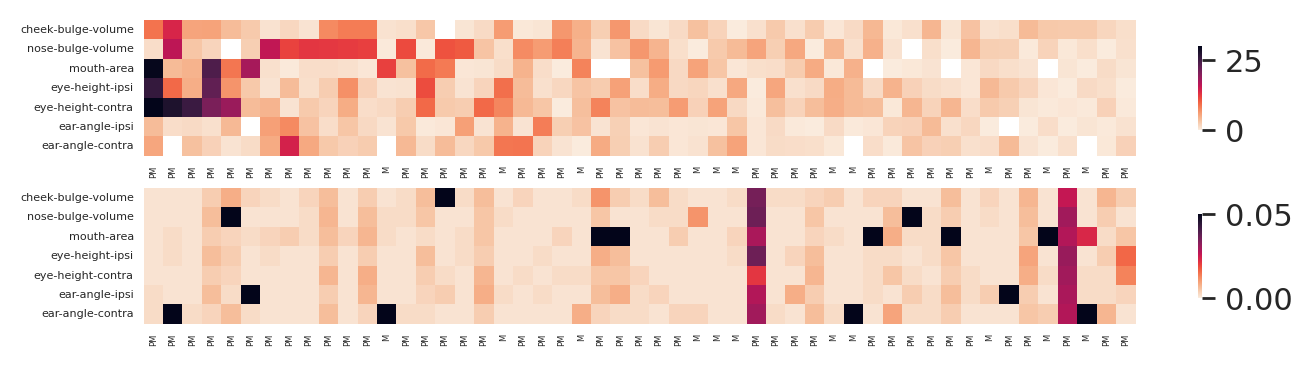

In [ ]:
def plot_explained_variance(sessions, fes, clusters, control, scores):
    fe_names = np.array(["cheek-bulge-volume",
                         "nose-bulge-volume",
                         "mouth-area",
                         "eye-height-ipsi",
                         "eye-height-contra",
                         "ear-angle-ipsi",
                         "ear-angle-contra"], dtype=object)
    clusters = np.array(["_".join(s) + "_" + c
                         for s, c in zip(sessions, clusters)], dtype=object)
    cluster_names = np.unique(clusters)
    scores = np.array([np.mean(np.clip(np.array(r), 0, None), axis=0) for r in scores],
                      dtype=object)
    data = []
    data_sig = []
    for fe in fe_names:
        row = []
        row_sig = []
        row_mask = []
        for cluster in cluster_names:
            mask = ((fes == fe) & (clusters == cluster) & ~control).values
            if mask.sum() == 0:
                continue
            scores_masked = scores[mask][0]
            max_r = scores_masked * 100
            mask = ((fes == fe) & (clusters == cluster) & control).values
            if mask.sum() == 0:
                continue
            scores_masked = np.concatenate(scores[mask], axis=0)
            n_failures = np.sum(scores_masked * 100 >= max_r)
            p_val = (n_failures + 1) / (len(scores_masked) + 1)
            row.append(max_r)
            row_sig.append(p_val)
        data.append(row)
        data_sig.append(row_sig)
    data = np.array(data)
    data_sig = np.array(data_sig)
    data_mask = (data_sig < 0.05)
    # Sort columns by maximum absolute value
    max_abs_values = np.max(np.abs(data), axis=0, initial=0, where=data_mask)
    sorted_indices = np.argsort(max_abs_values)[::-1]  # Descending order
    cutoff_idx = np.where(max_abs_values[sorted_indices] > 2.0)[0][-1]
    sorted_data = data[:, sorted_indices][:, :(cutoff_idx + 1)]
    sorted_sig = data_sig[:, sorted_indices][:, :(cutoff_idx + 1)]
    sorted_mask = data_mask[:, sorted_indices][:, :(cutoff_idx + 1)]
    sorted_data = np.where(sorted_mask, sorted_data, np.nan)
    sorted_cluster_names = np.array(cluster_names)[sorted_indices][:(cutoff_idx + 1)]
    print("data shape:", sorted_data.shape)
    fig, axs = plt.subplots(nrows=2, figsize=(8, 2), dpi=200)
    cbar_kws = {
        'shrink': 0.6, # Shrink the colorbar
    }
    sns.heatmap(sorted_sig, 
                xticklabels=sorted_cluster_names, yticklabels=fe_names,
                cmap="rocket_r", square=True, vmin=0, vmax=0.05, cbar_kws=cbar_kws, ax=axs[1])
    cbar_kws = {
        'shrink': 0.6, # Shrink the colorbar
        'format': '%.0f',  # Format as integers
    }
    sns.heatmap(sorted_data, 
                xticklabels=sorted_cluster_names, yticklabels=fe_names,
                cmap="rocket_r", square=True, vmin=0, vmax=None, cbar_kws=cbar_kws, ax=axs[0])
    # Set smaller font size for x and y labels
    axs[0].set_xticklabels(["PM" if "premotor" in x.get_text() else "M"
                            for x in axs[0].get_xticklabels()], fontsize=3)
    axs[0].set_yticklabels(axs[0].get_yticklabels(), fontsize=4)
    axs[1].set_xticklabels(["PM" if "premotor" in x.get_text() else "M"
                            for x in axs[1].get_xticklabels()], fontsize=3)
    axs[1].set_yticklabels(axs[1].get_yticklabels(), fontsize=4)
    # Shrink x and y tick marks
    axs[0].tick_params(axis='both', which='both', bottom=False, left=False, length=0)
    axs[1].tick_params(axis='both', which='both', bottom=False, left=False, length=0)

def left_right_to_ipsi_contra(row):
    date = row["date"]
    mouse = row["mouse"]
    fe = row["fe"]
    craniotomy = CRANIOTOMY_MAP[mouse]
    if isinstance(craniotomy, dict):
        craniotomy = craniotomy[date]
    if fe.endswith(craniotomy):
        return fe.replace(craniotomy, "ipsi")
    else:
        if craniotomy == "left":
            return fe.replace("right", "contra")
        else:
            return fe.replace("left", "contra")

plot_df = prediction_stats_df.query(
    "~measurement_group.str.startswith('fe_pcs') &" \
    "~measurement_group.str.startswith('d_fe_pcs') &" \
    "~measurement_group.str.startswith('d_') &" \
    "(stat_group.str.endswith('_sw') |" \
    " stat_group.str.endswith('_sw_control')) &" \
    "stat_name == 'deviance_explained'"
)
plot_df["fe"] = plot_df["measurement_group"].apply(lambda x: x.split("_to_")[0])
plot_df["fe"] = plot_df.apply(left_right_to_ipsi_contra, axis=1)
plot_df["cluster"] = plot_df["measurement_group"].apply(lambda x: x.split("_to_")[1])
plot_df["control"] = plot_df["stat_group"].apply(
    lambda x: True if x.endswith('_control') else False
)
plot_explained_variance(plot_df["session"],
                        plot_df["fe"],
                        plot_df["cluster"],
                        plot_df["control"],
                        plot_df["stat_value_smooth"])
save_figure(OUTPUT_DIR / "sw_single",
            "poisson_sw_single_variance_explained_heatmap_significant", plt.gcf(), dpi=200)

## Panel K

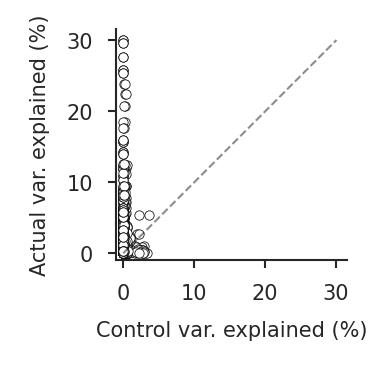

In [ ]:
plot_df = prediction_stats_df.query(
    "~measurement_group.str.startswith('fe_pcs') &" \
    "~measurement_group.str.startswith('d_fe_pcs') &" \
    "~measurement_group.str.startswith('d_') &" \
    "(stat_group.str.endswith('_sw') |" \
    " stat_group.str.endswith('_sw_control')) &" \
    "stat_name == 'deviance_explained'"
)
plot_df["group"] = plot_df["stat_group"].apply(
    lambda x: "control" if x.endswith('_control') else "actual"
)
plot_df["variance_explained"] = plot_df["stat_value_smooth"].apply(
    lambda x: np.mean([np.clip(xi, 0, None) for xi in x]) * 100
)
# Reshape data for scatter plot
actual_data = plot_df.query("group == 'actual'")[["session", "measurement_group", "variance_explained"]]
control_data = plot_df.query("group == 'control'")[["session", "measurement_group", "variance_explained"]]
# Merge actual and control data
scatter_df = actual_data.merge(
    control_data, 
    on=["session", "measurement_group"], 
    suffixes=("_actual", "_control")
)

fig, ax = plt.subplots(figsize=(1, 1), dpi=300)

# Plot diagonal line for reference (y = x)
max_val = max(scatter_df["variance_explained_actual"].max(), 
              scatter_df["variance_explained_control"].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=0.5)

# Create scatter plot
sns.scatterplot(data=scatter_df, 
                x="variance_explained_control",
                y="variance_explained_actual",
                s=5,
                edgecolor="black",
                color="white",
                ax=ax)

ax.set_ylabel("Actual var. explained (%)")
ax.set_xlabel("Control var. explained (%)")
sns.despine(fig)

# Make axes equal for better comparison
ax.set_aspect('equal')
ax.set_xlim(-1, max_val * 1.05)
ax.set_ylim(-1, max_val * 1.05)

from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

# Make axis lines and ticks thinner
ax.tick_params(axis='both', which='both', width=0.5, length=2)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Scale all text elements
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(5)

save_figure(OUTPUT_DIR / "sw_single",
            "poisson_sw_single_variance_explained_scatter_control_vs_actual", plt.gcf(), dpi=200)